# Подготовка к отчету

In [ ]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Список файлов:", files)

airlines_df = pd.read_csv(os.path.join(path, 'airlines.csv'))
flights_df = pd.read_csv(os.path.join(path, 'flights.csv'))
airports_df = pd.read_csv(os.path.join(path, 'airports.csv'))

flights_with_airlines = flights_df.merge(airlines_df, left_on='AIRLINE', right_on='IATA_CODE', how='left')
flights_with_airports = flights_with_airlines.merge(airports_df, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')


100%|██████████| 191M/191M [00:01<00:00, 148MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/usdot/flight-delays/versions/1
Список файлов: ['airports.csv', 'flights.csv', 'airlines.csv']


<ipython-input-2-2cda712280fc>:14: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights_df = pd.read_csv(os.path.join(path, 'flights.csv'))


# Отчет о Задержках Авиарейсов для Министерства Транспорта
 В отчете представлен анализ задержек авиарейсов, раскрывающий их характер и причины возникновения. Цель отчета- предоставить министерсву транспорта информацию об общих проблемных точках для большинства авиарейсов с целью помочь устранить проблемы, связанные с задержками.

# Вопросы, которые будут рассмотрены в отчете:


1.    Распределение задержек по дням недели и времени суток
2.    Как время задержи менятеся в зависимости от времени суток
3.    Статистика задержек по месяцам
4. Среднее время задержки по аэропортам и зависимость количества задержек от количества рейсов
5. Статистика по авиакомпаниям






# 1. Распределение задержек по дням недели и времени суток

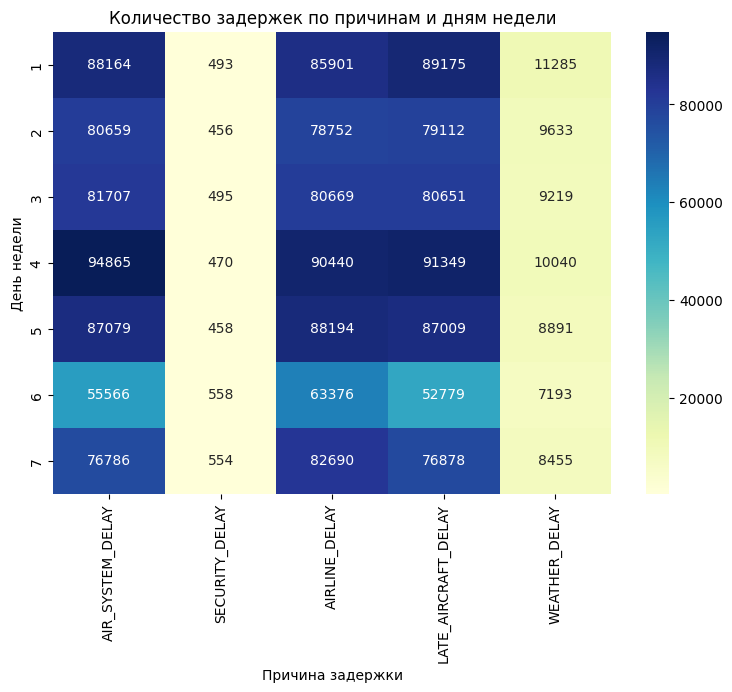

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

weekday_delay = flights_with_airports.groupby(['DAY_OF_WEEK'])[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].apply(lambda x: (x > 0).sum())

plt.figure(figsize=(9, 6))
sns.heatmap(weekday_delay, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Количество задержек по причинам и дням недели')
plt.xlabel('Причина задержки')
plt.ylabel('День недели')
plt.show()

flights_with_airports['DEPARTURE_HOUR'] = (flights_with_airports['SCHEDULED_DEPARTURE'] // 100).astype(int)



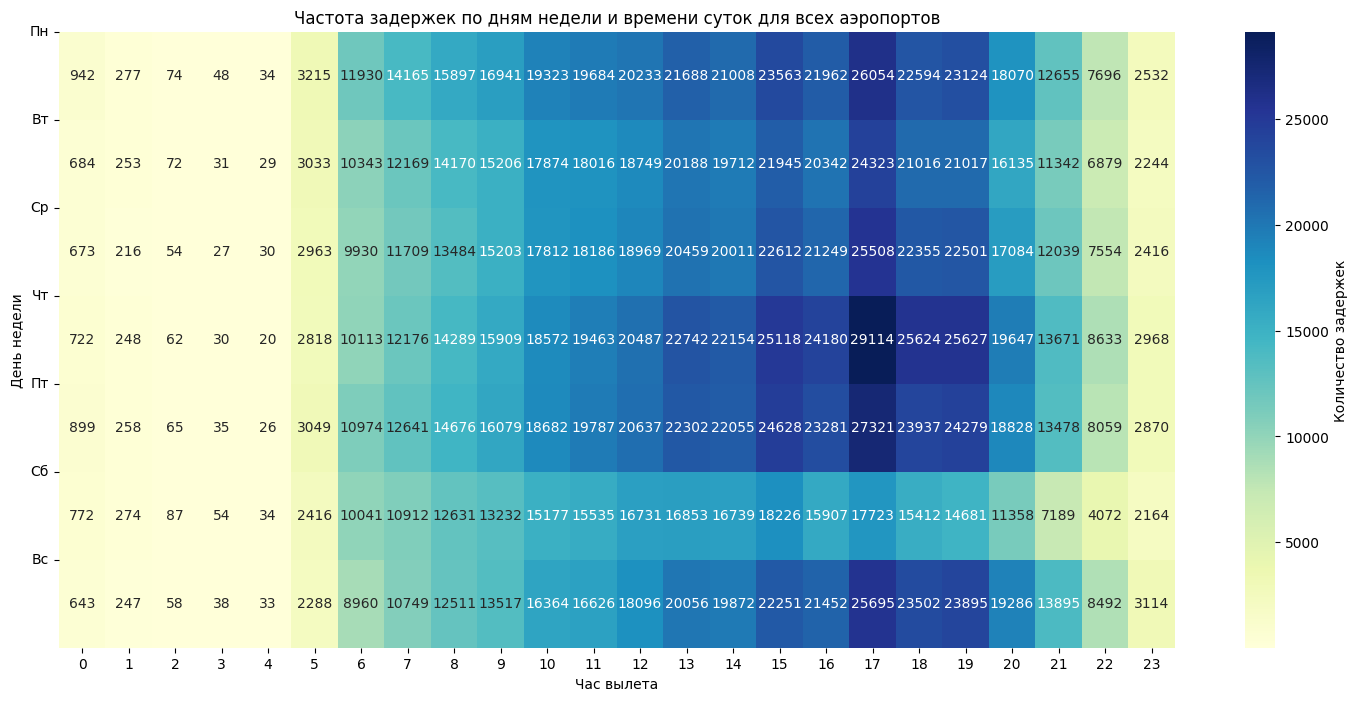

In [ ]:
data_all = flights_with_airports[flights_with_airports['DEPARTURE_DELAY'] > 0] \
    .groupby(['DAY_OF_WEEK', 'DEPARTURE_HOUR']).size().unstack(fill_value=0)

plt.figure(figsize=(18, 8))
sns.heatmap(data_all, cmap="YlGnBu", annot=True, fmt="d", cbar_kws={'label': 'Количество задержек'})
plt.title('Частота задержек по дням недели и времени суток для всех аэропортов')
plt.xlabel('Час вылета')
plt.ylabel('День недели')
plt.yticks([0, 1, 2, 3, 4, 5, 6], ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], rotation=0)
plt.show()

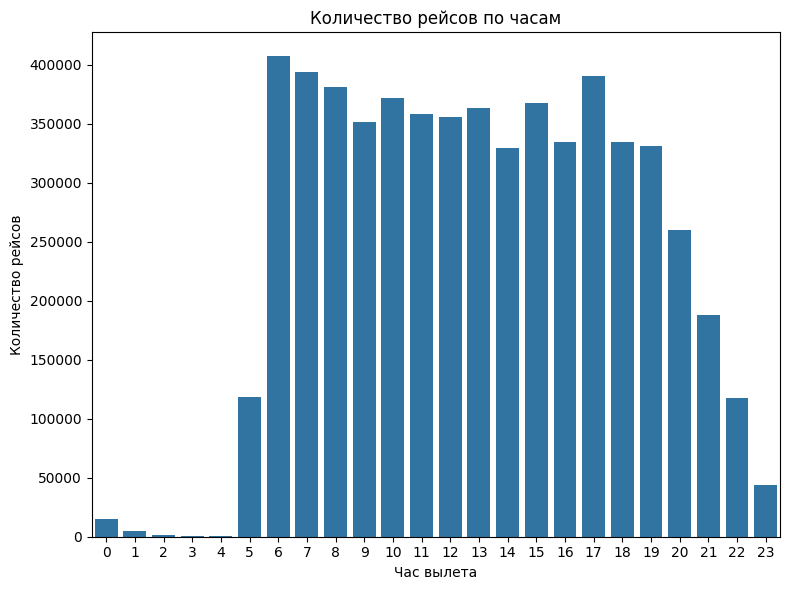

In [ ]:
flights_with_airports['DEPARTURE_HOUR'] = (flights_with_airports['SCHEDULED_DEPARTURE'] // 100).astype(int)
flights_hour = flights_with_airports['DEPARTURE_HOUR'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=flights_hour.index, y=flights_hour.values, dodge=False)
plt.xlabel('Час вылета')
plt.ylabel('Количество рейсов')
plt.title('Количество рейсов по часам')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()



# Вывод по вопросу 1:
Анализ задержек по дням недели и времени суток показывает, что задержки наиболее часты днем и вечером, когда количество рейсов находится на пиковом уровне. Наибольшее число задержек происходит в начале и в конце рабочей недели, что, вероятно, связано с высокой загруженностью аэропортов в эти дни. Основными причинами задержек являются факторы, зависящие от авиакомпаний, и опоздания предыдущих рейсов.

Стоит отметить, что общее количество рейсов остаётся примерно одинаковым с 6 утра до 19 вечера, однако пик задержек приходится на 17 часов. Это свидетельствует о накопительном эффекте: задержки, возникшие ранее в течение дня, усиливаются и накапливаются ближе к вечеру, что приводит к перегрузке системы и росту числа задержек именно к концу рабочего дня.


# 2. Как время задержи меняется в зависимости от времени суток

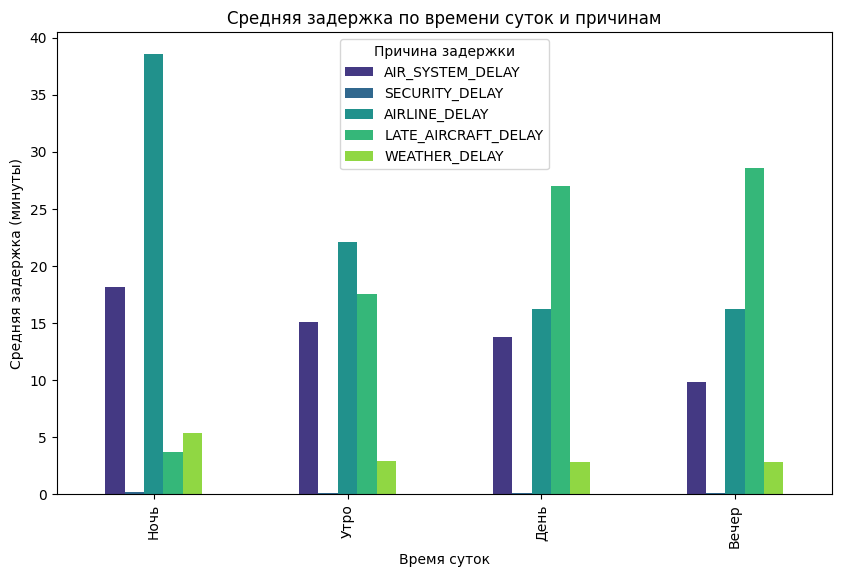

In [ ]:
flights_with_airports['DEPARTURE_HOUR'] = (flights_with_airports['SCHEDULED_DEPARTURE'] // 100).astype(int)
flights_with_airports['TIME_OF_DAY'] = pd.cut(flights_with_airports['DEPARTURE_HOUR'], bins=[0, 6, 12, 18, 24], labels=['Ночь', 'Утро', 'День', 'Вечер'])

delays = flights_with_airports[(flights_with_airports[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']] > 0).any(axis=1)]

time_delays = delays.groupby('TIME_OF_DAY', observed=False)[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].mean()

colors = sns.color_palette("viridis", n_colors=len(time_delays.columns))

time_delays.plot(kind='bar', figsize=(10, 6), color=colors)
plt.title('Средняя задержка по времени суток и причинам')
plt.xlabel('Время суток')
plt.ylabel('Средняя задержка (минуты)')
plt.legend(title='Причина задержки')
plt.show()


# Выводы по вопросу 2:
На графике видно, что задержки по вине авиакомпаний наиболее продолжительны ночью, что указывает на необходимость оптимизации работы авиакомпаний именно в эти часы и усиленного контроля за выполнением операций в ночное время. Также ночью значительное время занимают задержки, связанные с системой управления воздушным движением, что требует дополнительных ресурсов и внимания к этому аспекту в ночные часы.

Кроме того, днем и вечером отмечаются значительные задержки из-за позднего прибытия предыдущих рейсов. Это опять говорит о необходимости пересмотра расписания и выделения дополнительных рейсов, чтобы минимизировать влияние накопленных задержек на дальнейшие рейсы.

# 3. Статистика задержек по месяцам

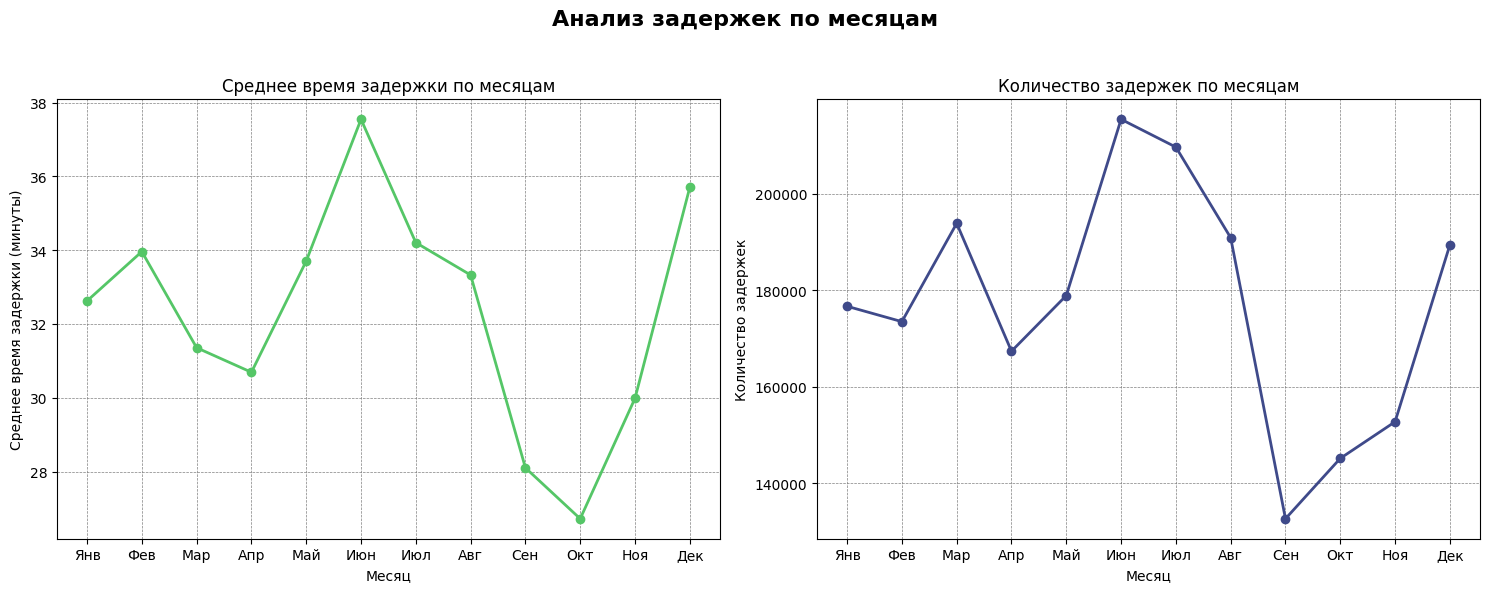

In [ ]:
delays = flights_with_airports[flights_with_airports['DEPARTURE_DELAY'] > 0]

month_means = delays.groupby('MONTH')['DEPARTURE_DELAY'].mean().reset_index()
month_counter = delays.groupby('MONTH')['DEPARTURE_DELAY'].count().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(month_means['MONTH'], month_means['DEPARTURE_DELAY'], marker='o', color='#55c667', linewidth=2)
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Среднее время задержки (минуты)')
axes[0].set_title('Среднее время задержки по месяцам')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)

axes[1].plot(month_counter['MONTH'], month_counter['DEPARTURE_DELAY'], marker='o', color='#3f4a8a', linewidth=2)
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Количество задержек')
axes[1].set_title('Количество задержек по месяцам')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('Анализ задержек по месяцам', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Вывод по вопросу 3:
Самое высокое среднее время задержки наблюдается в июне, что может свидетельствовать о перегруженности аэропортов в начале летнего сезона отпусков.
Аналогично, количество задержек также резко возрастает в летние месяцы, достигая пика в июне.
Начиная с сентября, среднее время задержки и их количество снижаются, достигая минимальных значений в октябре. Однако с ноября наблюдается тенденция к росту, что можно объяснить началом праздничного сезона.


# 4. Среднее время задержек по аэропортам и зависимость количества задержек от количества рейсов

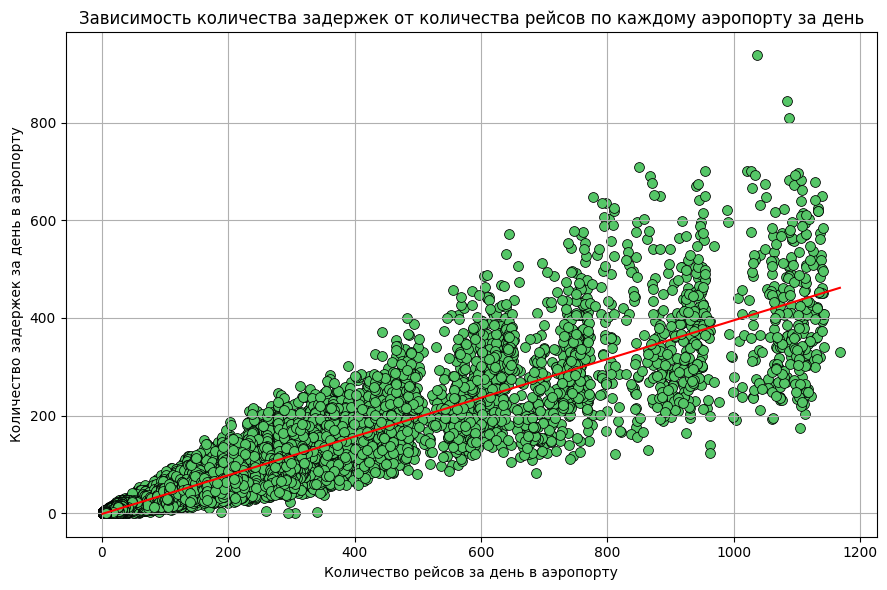

In [ ]:
delays = flights_with_airports[flights_with_airports['DEPARTURE_DELAY'] > 0]
total_flights = flights_with_airports.groupby(['ORIGIN_AIRPORT', 'YEAR', 'MONTH', 'DAY']).size()
total_delays = delays.groupby(['ORIGIN_AIRPORT', 'YEAR', 'MONTH', 'DAY']).size()
daily_airport = pd.concat([total_flights, total_delays], axis=1, keys=['Total_Flights', 'Total_Delays']).fillna(0)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=daily_airport, x='Total_Flights', y='Total_Delays', s=50, color='#55c667', edgecolor="black")
sns.regplot(data=daily_airport, x='Total_Flights', y='Total_Delays', scatter=False, color='red', line_kws={"linewidth": 1.5}, ci=None)
plt.xlabel('Количество рейсов за день в аэропорту')
plt.ylabel('Количество задержек за день в аэропорту')
plt.title('Зависимость количества задержек от количества рейсов по каждому аэропорту за день')
plt.grid(True)
plt.tight_layout()
plt.show()


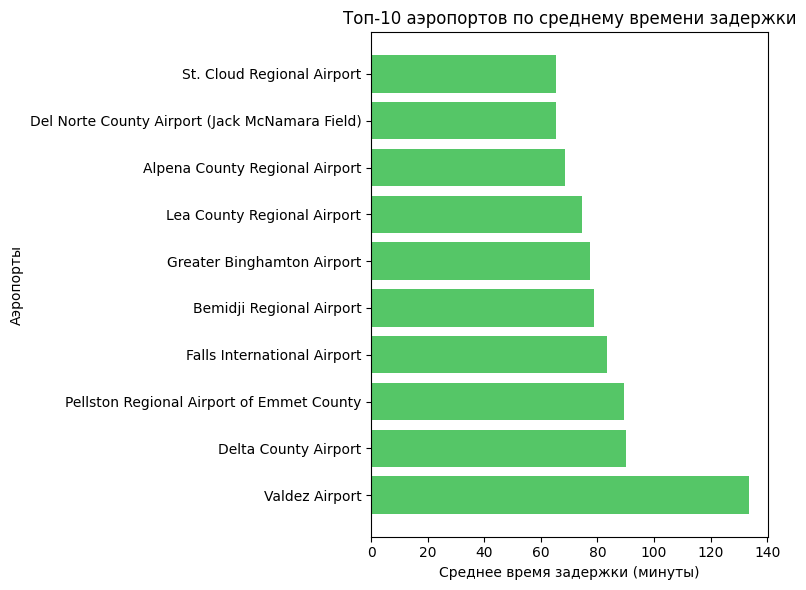

In [ ]:
airport_delay = flights_with_airports[flights_with_airports['DEPARTURE_DELAY'] > 0].groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().reset_index()
airport_delay = airport_delay.merge(airports_df, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE')
top_airports = airport_delay.nlargest(10, 'DEPARTURE_DELAY').sort_values(by='DEPARTURE_DELAY')

plt.figure(figsize=(8, 6))
plt.barh(top_airports['AIRPORT'], top_airports['DEPARTURE_DELAY'], color='#55c667')
plt.xlabel('Среднее время задержки (минуты)')
plt.ylabel('Аэропорты')
plt.title('Топ-10 аэропортов по среднему времени задержки')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# Вывод по вопросу 4:
Заметна явная положительная корреляция между количеством рейсов и количеством задержек. Это может говорить о том, что чем больше рейсов в день выполняется в аэропорту, тем больше вероятность возникновения задержек. Таким образом, в крупных аэропортах с высокой загруженностью наблюдаются частые задержки, что требует оптимизации процесса отправки и прибытия рейсов для уменьшения этих задержек.

Аэропорт Valdez имеет самое большое среднее время задержки (более 120 минут).  Для понимания причины следует более детально разобраться в вопросе.

# Выясним, чем вызвано аномальное среднее время задержек для аэропорта Valdez Airport

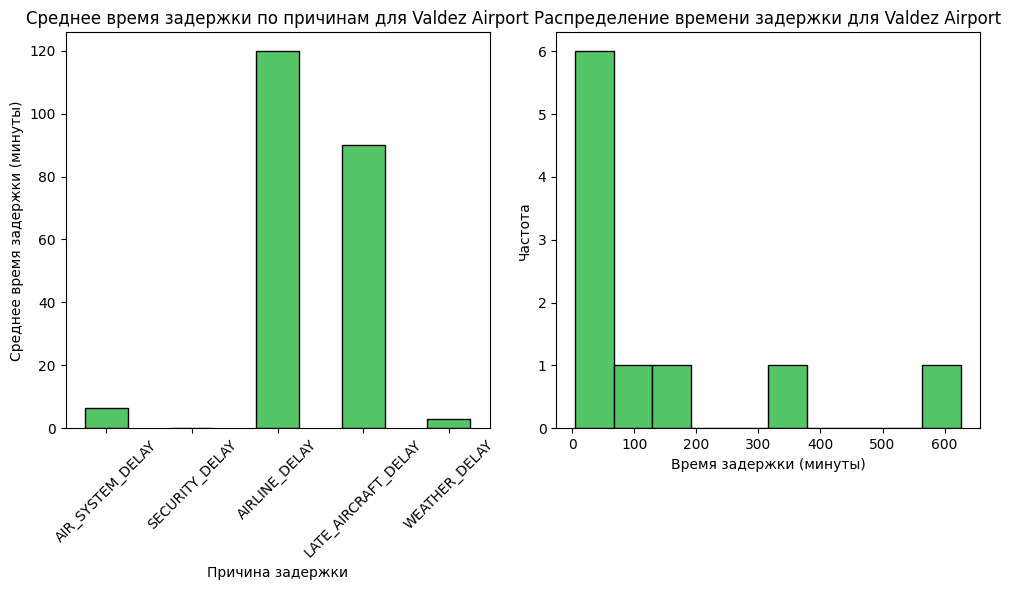

In [ ]:
valdez_delays = flights_with_airports[(flights_with_airports['AIRPORT'] == 'Valdez Airport') & (flights_with_airports['DEPARTURE_DELAY'] > 0)]
valdez_delay_reasons = valdez_delays[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

axes[0].bar(valdez_delay_reasons.index, valdez_delay_reasons.values, color='#55c667', width=0.5, edgecolor='black')
axes[0].set_xlabel('Причина задержки')
axes[0].set_ylabel('Среднее время задержки (минуты)')
axes[0].set_title('Среднее время задержки по причинам для Valdez Airport')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(valdez_delays['DEPARTURE_DELAY'], bins=10, color='#55c667', edgecolor='black')
axes[1].set_xlabel('Время задержки (минуты)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение времени задержки для Valdez Airport')

plt.tight_layout()
plt.show()



# Вывод по аэропорту Valdez Airport
Основными причинами задержек являются: задержка по вине авиакомпаний и задержка предыдущего рейса. Задержка по вине авиакомпаний имеет максимальную среднюю продолжительность, превышающую 120 минут, что указывает на значительные проблемы с работой авиакомпаний в этом аэропорту.
Задержки из-за позднего прибытия самолета также значительны, указывая на сложность восстановления графика после сбоев.

Большинство задержек в аэропорту Valdez относительно короткие, но встречаются и крайне продолжительные задержки, доходящие до 600 минут. Это указывает на возможные сложности в оперативном управлении и отсутствии быстрых решений для восстановления расписания в случае крупных задержек.

# 5. Статистика по авиакомпаниям

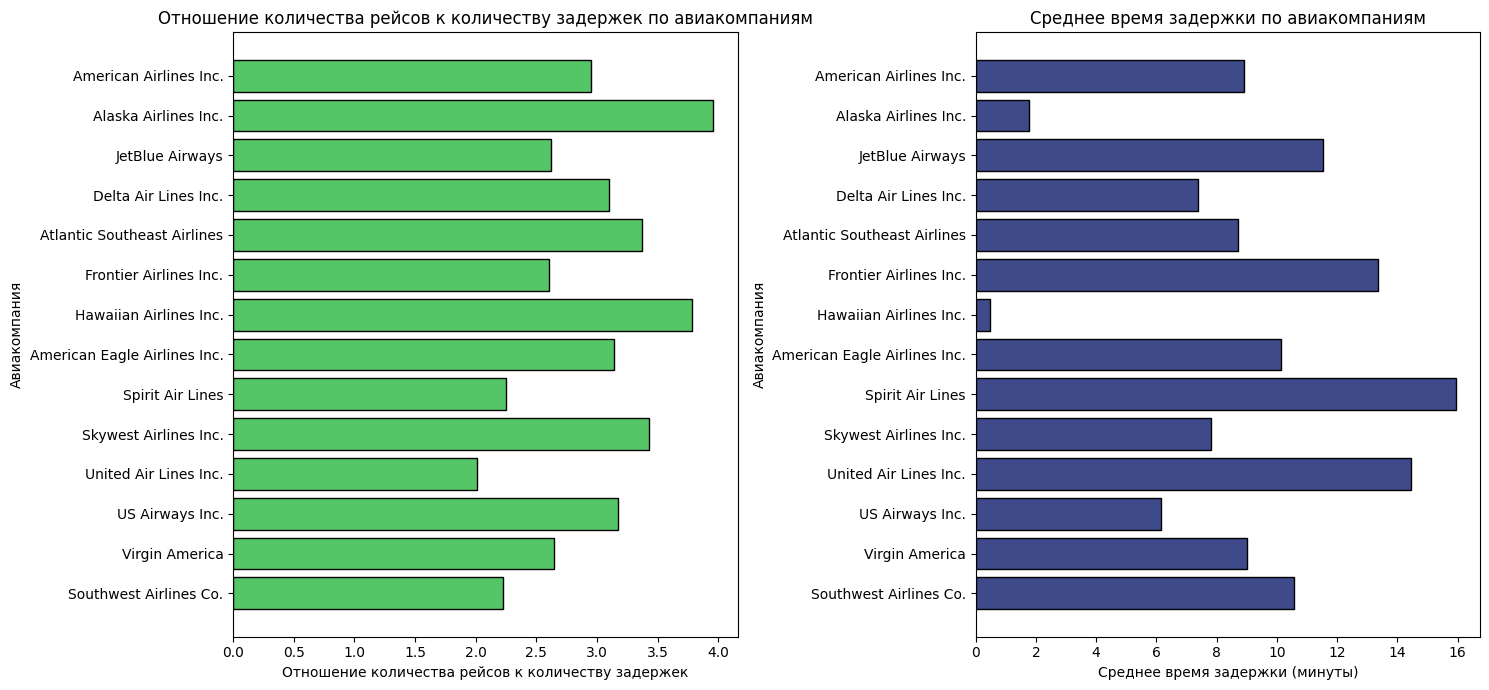

In [ ]:
airline_delay = flights_with_airports.groupby('AIRLINE_x')['DEPARTURE_DELAY'].mean().reset_index()
airline_delay = airline_delay.merge(airlines_df, left_on='AIRLINE_x', right_on='IATA_CODE')

total_flights = flights_with_airports.groupby('AIRLINE_x').size()
total_delays = flights_with_airports[flights_with_airports['DEPARTURE_DELAY'] > 0].groupby('AIRLINE_x').size()

airline_data = pd.DataFrame({
    'Total_Flights': total_flights,
    'Total_Delays': total_delays
}).fillna(0)

airline_data['Flights_to_Delays_Ratio'] = airline_data['Total_Flights'] / airline_data['Total_Delays']
airline_data['Flights_to_Delays_Ratio'] = airline_data['Flights_to_Delays_Ratio'].replace([float('inf'), float('nan')], 0)

airline_data = airline_data.merge(airlines_df, left_index=True, right_on='IATA_CODE')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(airline_data['AIRLINE'], airline_data['Flights_to_Delays_Ratio'], color='#55c667', edgecolor='black')
axes[0].set_xlabel('Отношение количества рейсов к количеству задержек')
axes[0].set_ylabel('Авиакомпания')
axes[0].set_title('Отношение количества рейсов к количеству задержек по авиакомпаниям')
axes[0].invert_yaxis()

axes[1].barh(airline_delay['AIRLINE'], airline_delay['DEPARTURE_DELAY'], color='#3f4a8a', edgecolor='black')
axes[1].set_xlabel('Среднее время задержки (минуты)')
axes[1].set_ylabel('Авиакомпания')
axes[1].set_title('Среднее время задержки по авиакомпаниям')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# Вывод по вопросу 5:
Анализ выявил четыре авиакомпании с наихудшими показателями по обоим графикам: JetBlue Airways, Frontier Airlines Inc., Spirit Air Lines и United Air Lines Inc. Эти компании демонстрируют высокое среднее время задержек и низкое отношение количества рейсов к числу задержек. Данные факты могут свидетельствовать о необходимости пересмотра их операционных процессов, улучшения управления временем и повышения эффективности обслуживания рейсов.

# Основные рекомендации и выводы по каждому из вопросов:
1. Ключевыми причинами задержек выступают ошибки авиакомпаний и накопительный эффект от задержек предыдущих рейсов, который достигает максимума ближе к вечеру.Для уменьшения накопительного эффекта задержек к вечеру стоит уменьшить плотность вылетов в дневные и вечерние часы.
2. Время задержек наиболее велико ночью и вечером. Для сокращения вечерних задержек можно пересмотреть график технического обслуживания и усилить контроль над работой авиакомпаний.
3. Задержки в летние месяцы выше как по времени, так и по количеству, что указывает на необходимость усиленных мер управления и координации в летний сезон.
4. Для крупных аэропортов стоит рассмотреть возможность увеличения пропускной способности и оптимизации процессов в часы пиковой нагрузки.
 Для уменьшения задержек в Valdez Airport рекомендуется провести анализ деятельности авиакомпаний, чтобы сократить время задержек аномальных случаев.
5. Рекомендуется провести аудит операционных процессов для JetBlue Airways, Frontier Airlines Inc., Spirit Air Lines, и United Air Lines Inc., чтобы устранить причины частых и долгих задержек.

# Заключение
Подводя итог, представленный отчет подчеркивает важность комплексного подхода к решению проблем задержек, начиная от оптимизации расписания, перераспределения ресурсов в пиковые периоды до усиления контроля за эффективностью работы как аэропортов, так и авиакомпаний.